Use case: PD

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) User Config

In [ ]:
DATA_PATH = "/content/Loan_default.csv"
OUTPUT_DIR = "/content/eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = "Default"
ID_COLS = ["LoanID"]

N_BINS = 10
SEED = 42

# 1) Load data

In [ ]:
df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")

df = df.dropna(subset=[TARGET]).copy()

df[TARGET] = df[TARGET].astype(int)

drop_cols = [c for c in ID_COLS if c in df.columns]
eda_df = df.drop(columns=drop_cols).copy()

# 2) Helper functions

In [ ]:
def save_table(df_table, name):
    path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df_table.to_csv(path, index=False)
    print(f"Saved: {path}")


def save_plot(name):
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: {path}")


def get_feature_types(data, target):
    features = [c for c in data.columns if c != target]

    numeric_features = data[features].select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_features = data[features].select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    return numeric_features, categorical_features


numeric_features, categorical_features = get_feature_types(eda_df, TARGET)

# 3)  Dataset overview

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [ ]:
overview = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_columns_including_target",
        "n_features",
        "n_numeric_features",
        "n_categorical_features",
        "target_column",
        "default_rate"
    ],
    "value": [
        len(eda_df),
        eda_df.shape[1],
        eda_df.shape[1] - 1,
        len(numeric_features),
        len(categorical_features),
        TARGET,
        eda_df[TARGET].mean()
    ]
})
display(overview)
save_table(overview, "dataset_overview")

,metric,value
0,n_observations,255347
1,n_columns_including_target,17
2,n_features,16
3,n_numeric_features,9
4,n_categorical_features,7
5,target_column,Default
6,default_rate,0.116128


Saved: /content/eda_outputs/dataset_overview.csv


# 4) Data types and missing values

,feature,dtype,missing_count,missing_rate,unique_values
0,Age,int64,0,0.0,52
1,Income,int64,0,0.0,114620
2,LoanAmount,int64,0,0.0,158729
3,CreditScore,int64,0,0.0,550
4,MonthsEmployed,int64,0,0.0,120
5,NumCreditLines,int64,0,0.0,4
6,InterestRate,float64,0,0.0,2301
7,LoanTerm,int64,0,0.0,5
8,DTIRatio,float64,0,0.0,81
9,Education,object,0,0.0,4


Saved: /content/eda_outputs/data_types_missing_values.csv


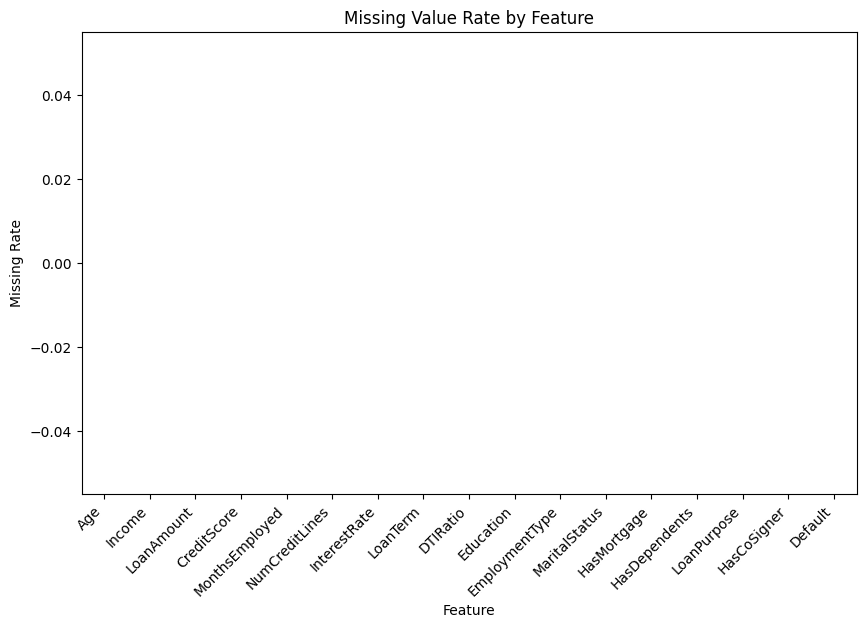

Saved: /content/eda_outputs/missing_value_rates.png


In [ ]:
dtype_table = pd.DataFrame({
    "feature": eda_df.columns,
    "dtype": eda_df.dtypes.astype(str).values,
    "missing_count": eda_df.isna().sum().values,
    "missing_rate": eda_df.isna().mean().values,
    "unique_values": eda_df.nunique(dropna=True).values
})
display(dtype_table)
save_table(dtype_table, "data_types_missing_values")


# 5) Target distribution

In [ ]:
target_dist = (
    eda_df[TARGET]
    .value_counts()
    .rename_axis("target_value")
    .reset_index(name="count")
)

target_dist["share"] = target_dist["count"] / target_dist["count"].sum()
save_table(target_dist, "target_distribution")


plt.figure(figsize=(6, 4))
eda_df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.xticks(rotation=0)
save_plot("target_distribution")

Saved: /content/eda_outputs/target_distribution.csv
Saved: /content/eda_outputs/target_distribution.png


# 6) Numeric feature summary

In [ ]:
target_dist = (
    eda_df[TARGET]
    .value_counts()
    .rename_axis("target_value")
    .reset_index(name="count")
)

target_dist["share"] = target_dist["count"] / target_dist["count"].sum()
save_table(target_dist, "target_distribution")


plt.figure(figsize=(6, 4))
eda_df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Default")
plt.ylabel("Count")
plt.xticks(rotation=0)
save_plot("target_distribution")

Saved: /content/eda_outputs/target_distribution.csv
Saved: /content/eda_outputs/target_distribution.png


# 7) Numeric feature summary

In [ ]:
numeric_summary = eda_df[numeric_features].describe().T.reset_index()
numeric_summary = numeric_summary.rename(columns={"index": "feature"})
save_table(numeric_summary, "numeric_feature_summary")
display(numeric_summary)

Saved: /content/eda_outputs/numeric_feature_summary.csv


,feature,count,mean,std,min,25%,50%,75%,max
0,Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
1,Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
2,LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
3,CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
4,MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
5,NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
6,InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
7,LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
8,DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


# 8) Categorical feature summary

In [ ]:
categorical_rows = []

for col in categorical_features:
    tmp = (
        eda_df[col]
        .value_counts(dropna=False)
        .reset_index()
    )
    tmp.columns = ["category", "count"]
    tmp["feature"] = col
    tmp["share"] = tmp["count"] / len(eda_df)
    categorical_rows.append(tmp[["feature", "category", "count", "share"]])

if categorical_rows:
    categorical_summary = pd.concat(categorical_rows, axis=0, ignore_index=True)
else:
    categorical_summary = pd.DataFrame()

save_table(categorical_summary, "categorical_feature_summary")
display(categorical_summary)

Saved: /content/eda_outputs/categorical_feature_summary.csv


,feature,category,count,share
0,Education,Bachelor's,64366,0.252073
1,Education,High School,63903,0.250259
2,Education,Master's,63541,0.248842
3,Education,PhD,63537,0.248826
4,EmploymentType,Part-time,64161,0.251270
5,EmploymentType,Unemployed,63824,0.249950
6,EmploymentType,Self-employed,63706,0.249488
7,EmploymentType,Full-time,63656,0.249292
8,MaritalStatus,Married,85302,0.334063
9,MaritalStatus,Divorced,85033,0.333010


# 9) Default rate by categorical feature

In [ ]:
cat_risk_rows = []

for col in categorical_features:
    tmp = (
        eda_df
        .groupby(col, dropna=False)
        .agg(
            n_obs=(TARGET, "count"),
            defaults=(TARGET, "sum"),
            default_rate=(TARGET, "mean")
        )
        .reset_index()
        .rename(columns={col: "category"})
    )

    tmp["feature"] = col
    tmp = tmp[["feature", "category", "n_obs", "defaults", "default_rate"]]
    cat_risk_rows.append(tmp)

    plt.figure(figsize=(8, 4))
    tmp_plot = tmp.sort_values("default_rate", ascending=False)
    plt.bar(tmp_plot["category"].astype(str), tmp_plot["default_rate"])
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    save_plot(f"default_rate_by_{col}")

if cat_risk_rows:
    categorical_default_rates = pd.concat(cat_risk_rows, axis=0, ignore_index=True)
else:
    categorical_default_rates = pd.DataFrame()

save_table(categorical_default_rates, "categorical_default_rates")
display(categorical_default_rates)

Saved: /content/eda_outputs/default_rate_by_Education.png
Saved: /content/eda_outputs/default_rate_by_EmploymentType.png
Saved: /content/eda_outputs/default_rate_by_MaritalStatus.png
Saved: /content/eda_outputs/default_rate_by_HasMortgage.png
Saved: /content/eda_outputs/default_rate_by_HasDependents.png
Saved: /content/eda_outputs/default_rate_by_LoanPurpose.png
Saved: /content/eda_outputs/default_rate_by_HasCoSigner.png
Saved: /content/eda_outputs/categorical_default_rates.csv


,feature,category,n_obs,defaults,default_rate
0,Education,Bachelor's,64366,7789,0.121011
1,Education,High School,63903,8230,0.128789
2,Education,Master's,63541,6908,0.108717
3,Education,PhD,63537,6726,0.105860
4,EmploymentType,Full-time,63656,6024,0.094634
5,EmploymentType,Part-time,64161,7677,0.119652
6,EmploymentType,Self-employed,63706,7302,0.114620
7,EmploymentType,Unemployed,63824,8650,0.135529
8,MaritalStatus,Divorced,85033,10657,0.125328
9,MaritalStatus,Married,85302,8869,0.103972


# 10) Numeric feature distributions by target

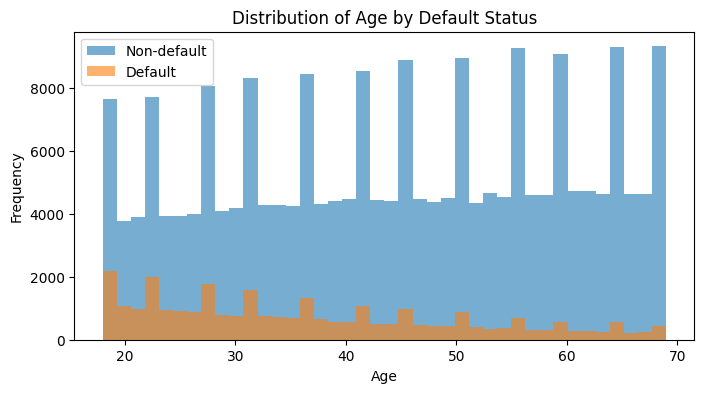

Saved: /content/eda_outputs/distribution_by_target_Age.png


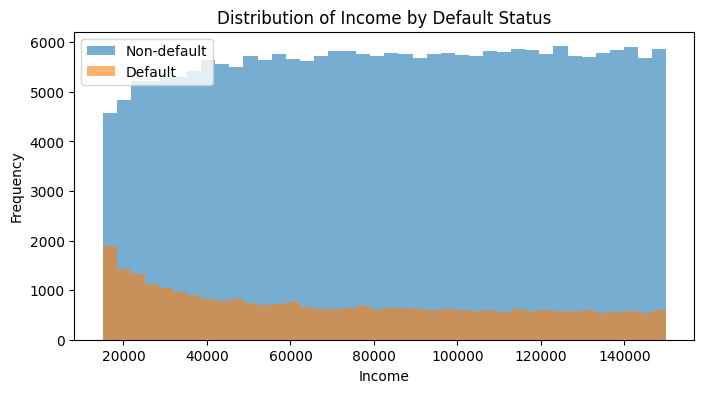

Saved: /content/eda_outputs/distribution_by_target_Income.png


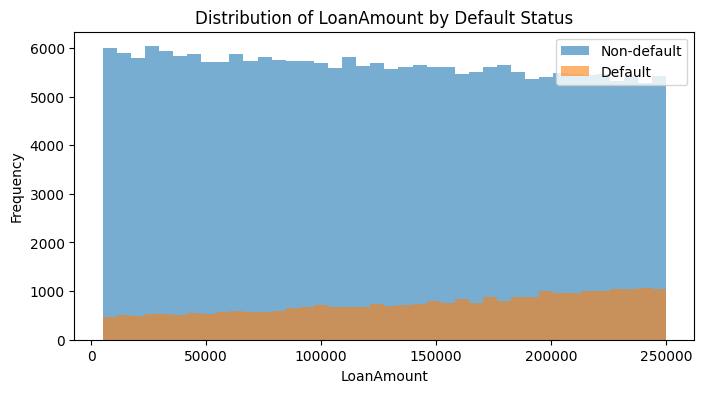

Saved: /content/eda_outputs/distribution_by_target_LoanAmount.png


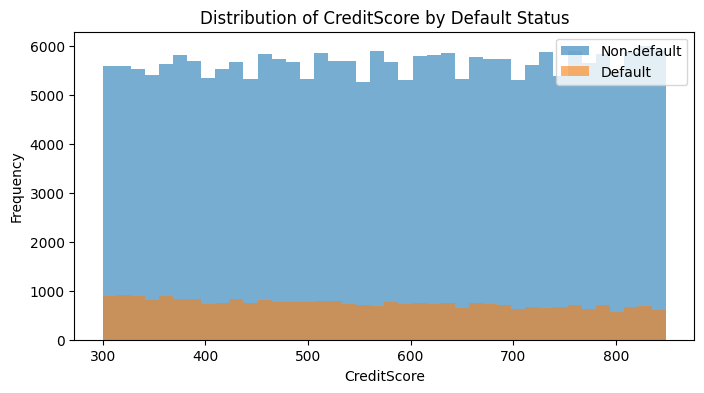

Saved: /content/eda_outputs/distribution_by_target_CreditScore.png


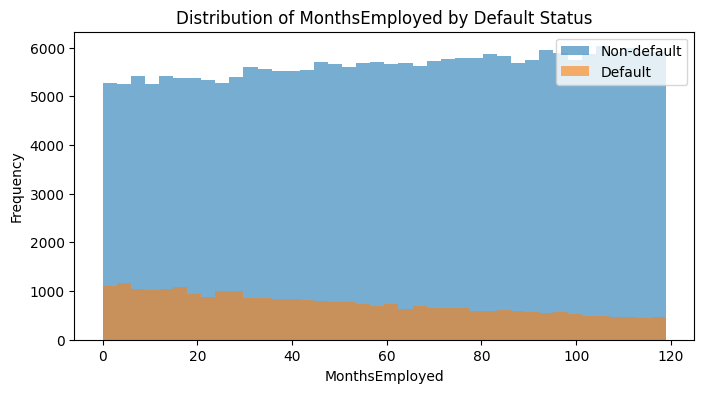

Saved: /content/eda_outputs/distribution_by_target_MonthsEmployed.png


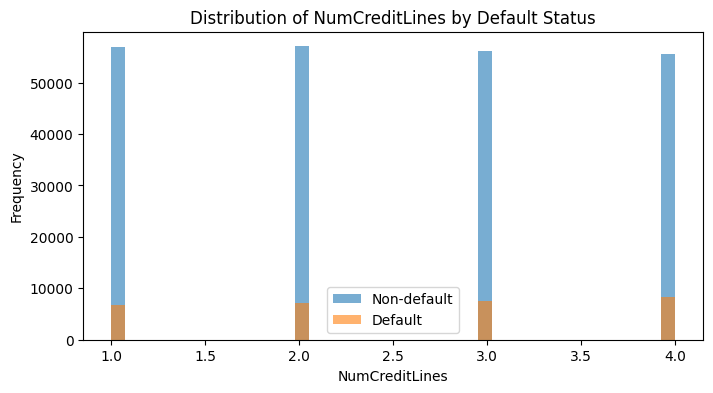

Saved: /content/eda_outputs/distribution_by_target_NumCreditLines.png


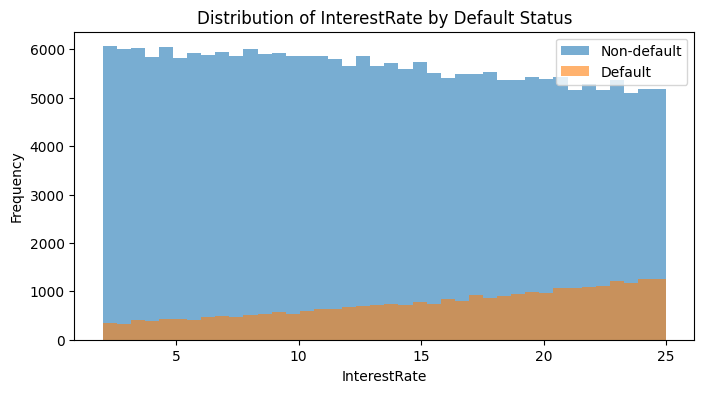

Saved: /content/eda_outputs/distribution_by_target_InterestRate.png


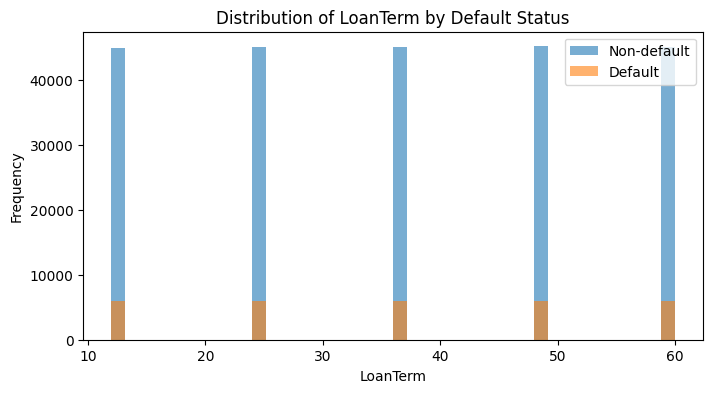

Saved: /content/eda_outputs/distribution_by_target_LoanTerm.png


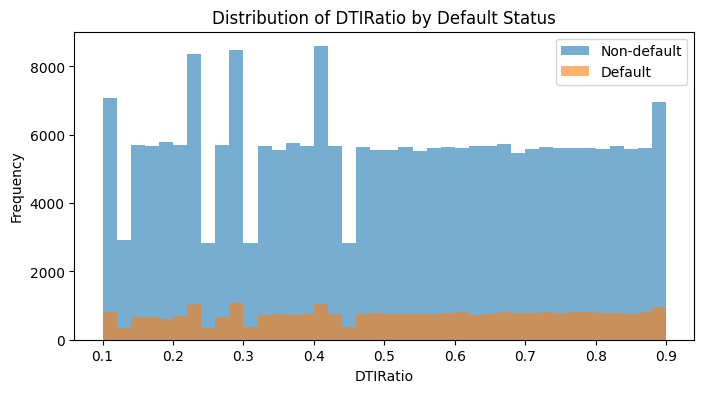

Saved: /content/eda_outputs/distribution_by_target_DTIRatio.png


In [ ]:
for col in numeric_features:
    plt.figure(figsize=(8, 4))

    eda_df.loc[eda_df[TARGET] == 0, col].dropna().plot(
        kind="hist",
        bins=40,
        alpha=0.6,
        label="Non-default"
    )

    eda_df.loc[eda_df[TARGET] == 1, col].dropna().plot(
        kind="hist",
        bins=40,
        alpha=0.6,
        label="Default"
    )

    plt.title(f"Distribution of {col} by Default Status")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    save_plot(f"distribution_by_target_{col}")


# 11)  Numeric risk quantile analysis

In [ ]:
numeric_risk_rows = []

for col in numeric_features:
    tmp = eda_df[[col, TARGET]].dropna().copy()

    if tmp[col].nunique() < 2:
        continue

    try:
        tmp["quantile_bin"] = pd.qcut(
            tmp[col],
            q=N_BINS,
            duplicates="drop"
        )
    except ValueError:
        continue

    risk_table = (
        tmp
        .groupby("quantile_bin", observed=False)
        .agg(
            n_obs=(TARGET, "count"),
            defaults=(TARGET, "sum"),
            default_rate=(TARGET, "mean"),
            min_value=(col, "min"),
            max_value=(col, "max"),
            mean_value=(col, "mean")
        )
        .reset_index()
    )

    risk_table["feature"] = col
    risk_table["bin_order"] = range(1, len(risk_table) + 1)

    numeric_risk_rows.append(
        risk_table[
            [
                "feature",
                "bin_order",
                "quantile_bin",
                "n_obs",
                "defaults",
                "default_rate",
                "min_value",
                "max_value",
                "mean_value"
            ]
        ]
    )

    plt.figure(figsize=(8, 4))
    plt.plot(risk_table["bin_order"], risk_table["default_rate"], marker="o")
    plt.title(f"Default Rate Across Quantiles: {col}")
    plt.xlabel("Quantile Bin")
    plt.ylabel("Default Rate")
    plt.grid(True, alpha=0.3)
    save_plot(f"default_rate_quantiles_{col}")

if numeric_risk_rows:
    numeric_default_rates = pd.concat(numeric_risk_rows, axis=0, ignore_index=True)
else:
    numeric_default_rates = pd.DataFrame()

save_table(numeric_default_rates, "numeric_default_rates_by_quantile")
display(numeric_default_rates)

Saved: /content/eda_outputs/default_rate_quantiles_Age.png
Saved: /content/eda_outputs/default_rate_quantiles_Income.png
Saved: /content/eda_outputs/default_rate_quantiles_LoanAmount.png
Saved: /content/eda_outputs/default_rate_quantiles_CreditScore.png
Saved: /content/eda_outputs/default_rate_quantiles_MonthsEmployed.png
Saved: /content/eda_outputs/default_rate_quantiles_NumCreditLines.png
Saved: /content/eda_outputs/default_rate_quantiles_InterestRate.png
Saved: /content/eda_outputs/default_rate_quantiles_LoanTerm.png
Saved: /content/eda_outputs/default_rate_quantiles_DTIRatio.png
Saved: /content/eda_outputs/numeric_default_rates_by_quantile.csv


,feature,bin_order,quantile_bin,n_obs,defaults,default_rate,min_value,max_value,mean_value
0,Age,1,"(17.999, 23.0]",29307,6245,0.213089,18.00,23.00,20.488552
1,Age,2,"(23.0, 28.0]",24451,4523,0.184982,24.00,28.00,26.007321
2,Age,3,"(28.0, 33.0]",24718,3871,0.156607,29.00,33.00,31.013310
3,Age,4,"(33.0, 38.0]",24665,3372,0.136712,34.00,38.00,35.993148
4,Age,5,"(38.0, 43.0]",24612,2738,0.111247,39.00,43.00,40.989070
...,...,...,...,...,...,...,...,...,...
72,DTIRatio,6,"(0.5, 0.58]",25339,2974,0.117368,0.51,0.58,0.544972
73,DTIRatio,7,"(0.58, 0.66]",25624,3069,0.119771,0.59,0.66,0.624832
74,DTIRatio,8,"(0.66, 0.74]",25597,3174,0.123999,0.67,0.74,0.704864
75,DTIRatio,9,"(0.74, 0.82]",25657,3195,0.124527,0.75,0.82,0.784929


# 12) Correlation analysis

In [ ]:
corr_features = numeric_features + [TARGET]
corr_matrix = eda_df[corr_features].corr(method="spearman")

corr_matrix.to_csv(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.csv"))

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Spearman Correlation Matrix")
save_plot("spearman_correlation_matrix")


target_corr = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .reset_index()
)

target_corr.columns = ["feature", "spearman_correlation_with_target"]
save_table(target_corr, "target_spearman_correlations")
display(target_corr)


Saved: /content/eda_outputs/spearman_correlation_matrix.png
Saved: /content/eda_outputs/target_spearman_correlations.csv


,feature,spearman_correlation_with_target
0,Age,-0.167791
1,InterestRate,0.131247
2,Income,-0.099087
3,MonthsEmployed,-0.097367
4,LoanAmount,0.086664
5,CreditScore,-0.034170
6,NumCreditLines,0.028330
7,DTIRatio,0.019240
8,LoanTerm,0.000546


# 12) EDA summary

In [ ]:
eda_summary = pd.DataFrame({
    "finding": [
        "Number of observations",
        "Number of model features",
        "Observed default rate",
        "Number of numeric features",
        "Number of categorical features",
        "Highest absolute Spearman target correlation",
        "Feature with highest absolute Spearman target correlation"
    ],
    "value": [
        len(eda_df),
        len(numeric_features) + len(categorical_features),
        eda_df[TARGET].mean(),
        len(numeric_features),
        len(categorical_features),
        target_corr["spearman_correlation_with_target"].abs().max()
        if len(target_corr) > 0 else np.nan,
        target_corr.iloc[0]["feature"]
        if len(target_corr) > 0 else None
    ]
})

save_table(eda_summary, "eda_summary_for_thesis")
display(eda_summary)

print("\nEDA completed.")
print(f"All outputs saved to: {OUTPUT_DIR}")

Saved: /content/eda_outputs/eda_summary_for_thesis.csv


,finding,value
0,Number of observations,255347
1,Number of model features,16
2,Observed default rate,0.116128
3,Number of numeric features,9
4,Number of categorical features,7
5,Highest absolute Spearman target correlation,0.167791
6,Feature with highest absolute Spearman target ...,Age



EDA completed.
All outputs saved to: /content/eda_outputs
